### Build a Simple LLM Application with LCEL
In this quickstart we'll show you how to build a simple LLM application with LangChain. This application will translate text from English into another language. This is a relatively simple LLM application - it's just a single LLM call plus some prompting. Still, this is a great way to get started with LangChain - a lot of features can be built with just some prompting and an LLM call!

After seeing this video, you'll have a high level overview of:

- Using language models

- Using PromptTemplates and OutputParsers

- Using LangChain Expression Language (LCEL) to chain components together

- Debugging and tracing your application using LangSmith

- Deploying your application with LangServe

In [4]:
### Open AI API Key and Open Source models--Llama3,Gemma2,mistral--Groq

import os
from dotenv import load_dotenv
load_dotenv()

import openai
openai.api_key=os.getenv("OPENAI_API_KEY")

groq_api_key=os.getenv("GROQ_API_KEY")


In [15]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
model=ChatGroq(model="openai/gpt-oss-120b",groq_api_key=groq_api_key)
model

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001CFB56503E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CFB564E450>, model_name='openai/gpt-oss-120b', groq_api_key=SecretStr('**********'))

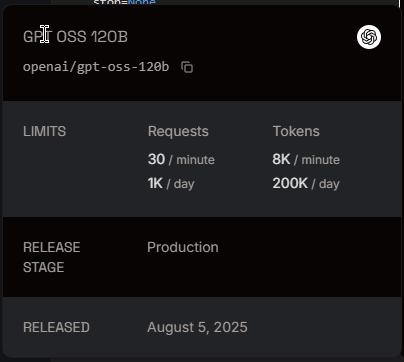

In [22]:
from langchain_core.messages import HumanMessage,SystemMessage

messages=[
    SystemMessage(content="Translate the following from English to German"),
    HumanMessage(content="Hello How are you?")
]

result=model.invoke(messages)

In [23]:
result.content

'**German:**  \nHallo, wie geht es dir?'

In [20]:
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()
parser.invoke(result)

'வணக்கம், நீங்கள் எப்படி இருக்கிறீர்கள்?'

In [21]:
### Using LCEL- chain the components
chain=model|parser
chain.invoke(messages)

'வணக்கம், நீங்கள் எப்படி இருக்கிறீர்கள்?'

In [20]:
### Prompt Templates
from langchain_core.prompts import ChatPromptTemplate

generic_template="Trnaslate the following into {language}:"

prompt=ChatPromptTemplate.from_messages(
    [("system",generic_template),("user","{text}")]
)



In [22]:
result=prompt.invoke({"language":"French","text":"Hello"})

In [23]:
result.to_messages()

[SystemMessage(content='Trnaslate the following into French:'),
 HumanMessage(content='Hello')]

In [24]:
##Chaining together components with LCEL
chain=prompt|model|parser
chain.invoke({"language":"French","text":"Hello"})

'Bonjour \n'